# Analisi cyclictest (analisys_def)
Confronto di tutti i file `cyclic_*.json` presenti nella cartella.
Grafici: jitter massimo per scenario, boxplot e distribuzione delle latenze, riepilogo (media/std/max/min) e jitter per thread.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
pd.options.display.float_format = '{:.3f}'.format


In [2]:
# Carica tutti i file JSON disponibili
BASE_DIR = Path('.')
json_files = sorted(BASE_DIR.glob('cyclic_*.json'))
print('Trovati', len(json_files), 'file:')
for f in json_files:
    print(' -', f.name)


Trovati 6 file:
 - cyclic_baseline_nopreempt_rt.json
 - cyclic_baseline_preempt_rt.json
 - cyclic_stress_100k_nopreempt_rt.json
 - cyclic_stress_100k_preempt_rt.json
 - cyclic_stress_1M_nopreempt_rt.json
 - cyclic_stress_1M_preempt_rt.json


In [12]:
# Normalizzazione nomi scenario e label leggibili
scenario_label_map = {
    'baseline_nopreempt_rt': 'Baseline No Preempt-RT',
    'baseline_preempt_rt': 'Baseline Preempt-RT',
    'stress_100k_nopreempt_rt': 'Stress 100k No Preempt-RT',
    'stress_100k_preempt_rt': 'Stress 100k Preempt-RT',
    'stress_1m_nopreempt_rt': 'Stress 1M No Preempt-RT',
    'stress_1m_preempt_rt': 'Stress 1M Preempt-RT',
}

def normalize_key(name: str) -> str:
    key = name.lower()
    key = key.replace('cyclic_', '')
    key = key.replace('stess', 'stress')
    key = key.replace('noprempt', 'nopreempt')
    key = key.replace('preemptrt', 'preempt_rt')
    key = key.replace('preempt-rt', 'preempt_rt')
    key = key.replace('nopreempt-rt', 'nopreempt_rt')
    key = key.replace('__', '_')
    return key

def prettify(scenario_key: str) -> str:
    key = normalize_key(scenario_key)
    if key in scenario_label_map:
        return scenario_label_map[key]
    return key.replace('_', ' ').title()


In [4]:
def load_json_hist(path: Path, scenario_key: str, scenario_label: str):
    data = json.loads(path.read_text())
    threads = data.get('thread', {})
    thread_rows, lat_rows = [], []
    for tid_str, info in threads.items():
        tid = int(tid_str)
        hist = {int(k): int(v) for k, v in (info.get('histogram') or {}).items()}
        lats = []
        for lat, cnt in hist.items():
            lats.extend([lat] * cnt)
        arr = np.array(lats, dtype=int)
        if arr.size:
            mean = float(arr.mean())
            std = float(arr.std())
            tmin = int(arr.min())
            tmax = int(arr.max())
            samples = int(arr.size)
            lat_rows.extend([(scenario_label, tid, int(v), scenario_key) for v in arr])
        else:
            mean = float(info.get('avg', np.nan))
            std = float('nan')
            tmin = int(info.get('min', np.nan)) if info.get('min') is not None else np.nan
            tmax = int(info.get('max', np.nan)) if info.get('max') is not None else np.nan
            samples = int(info.get('cycles', 0))
        thread_rows.append({
            'scenario_key': scenario_key,
            'scenario': scenario_label,
            'thread': tid,
            'min': tmin,
            'max': tmax,
            'mean': mean,
            'std': std,
            'samples': samples,
            'jitter': tmax - tmin if tmin == tmin and tmax == tmax else np.nan,
        })
    return thread_rows, lat_rows


In [5]:
# Costruzione DataFrame
thread_rows = []
latency_rows = []
for path in json_files:
    raw_key = path.stem.replace('cyclic_', '')
    scenario_key = normalize_key(raw_key)
    scenario_label = prettify(raw_key)
    trows, lrows = load_json_hist(path, scenario_key, scenario_label)
    thread_rows.extend(trows)
    latency_rows.extend(lrows)

thread_df = pd.DataFrame(thread_rows)
latency_df = pd.DataFrame(latency_rows, columns=['scenario', 'thread', 'latency', 'scenario_key'])

print('Scenari trovati:', sorted(thread_df.scenario.unique()))
print('Totale scenari:', thread_df.scenario.nunique())


Scenari trovati: ['Baseline No Preempt-RT', 'Baseline Preempt-RT', 'Stress 100k No Preempt-RT', 'Stress 100k Preempt-RT', 'Stress 1M No Preempt-RT', 'Stress 1M Preempt-RT']
Totale scenari: 6


In [6]:
# Riassunto per scenario basato sulle latenze raw
summary_df = (latency_df
    .groupby('scenario')
    .agg(mean=('latency', 'mean'),
         std=('latency', 'std'),
         min=('latency', 'min'),
         max=('latency', 'max'),
         samples=('latency', 'size'))
    .reset_index()
)
summary_df['jitter'] = summary_df['max'] - summary_df['min']
summary_df


,scenario,mean,std,min,max,samples,jitter
0,Baseline No Preempt-RT,5.997,2.946,2,52,239773,50
1,Baseline Preempt-RT,4.534,1.742,1,21,239761,20
2,Stress 100k No Preempt-RT,5.316,3.237,1,147,239766,146
3,Stress 100k Preempt-RT,4.760,2.833,1,40,239856,39
4,Stress 1M No Preempt-RT,4.820,2.538,1,161,2399915,160
5,Stress 1M Preempt-RT,4.514,2.769,1,53,239853,52


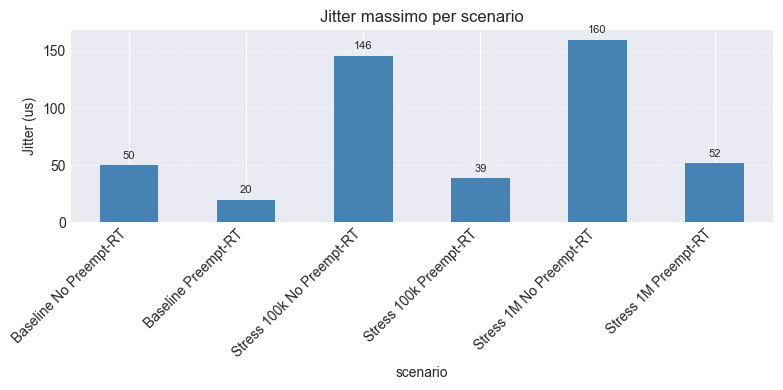

In [7]:
# Jitter massimo per scenario
fig, ax = plt.subplots(figsize=(8, 4))
summary_df.set_index('scenario')['jitter'].plot(kind='bar', ax=ax, color='steelblue')
ax.set_ylabel('Jitter (us)')
ax.set_title('Jitter massimo per scenario')
ax.grid(True, axis='y', linestyle='--', alpha=0.6)
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3, fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


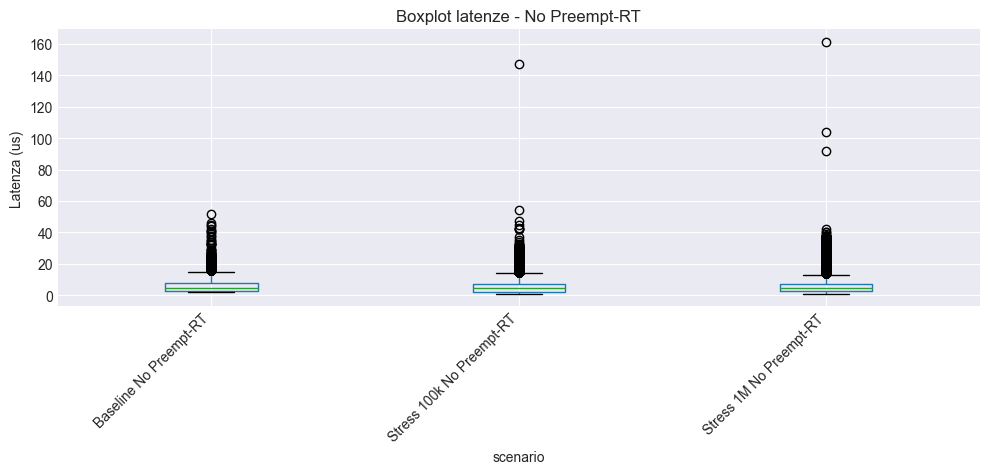

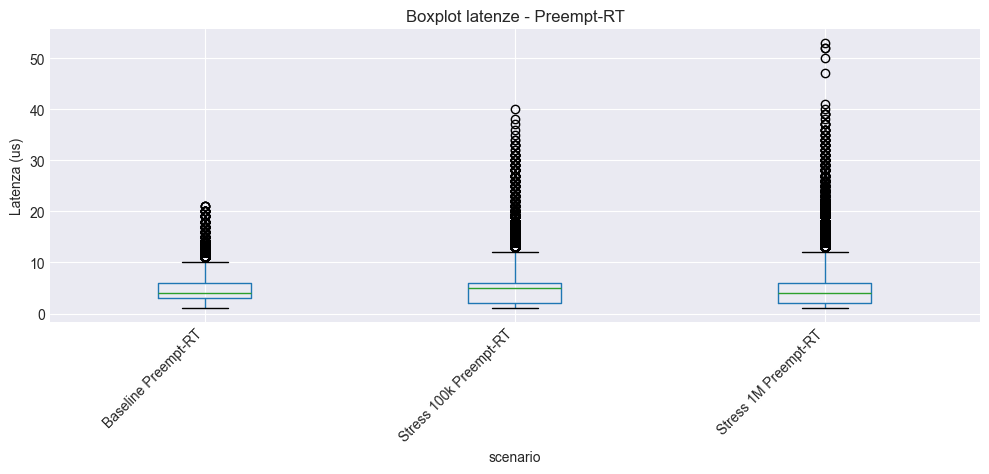

In [8]:
# Boxplot delle latenze separati: No Preempt-RT vs Preempt-RT (stile semplice, solo mediana)
if latency_df.empty:
    print('Nessuna latenza disponibile per i boxplot')
else:
    label_to_key = thread_df[['scenario','scenario_key']].drop_duplicates().set_index('scenario')['scenario_key']
    nopre = [s for s,k in label_to_key.items() if 'nopreempt_rt' in k]
    pre   = [s for s,k in label_to_key.items() if 'preempt_rt' in k and 'nopreempt_rt' not in k]

    def plot_group(labels, title):
        if not labels:
            print(f'Nessun scenario per {title}')
            return
        subset = latency_df[latency_df['scenario'].isin(labels)]
        fig, ax = plt.subplots(figsize=(10, 5))
        subset.boxplot(column='latency', by='scenario', ax=ax)
        ax.set_ylabel('Latenza (us)')
        ax.set_title(title)
        plt.suptitle('')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    plot_group(nopre, 'Boxplot latenze - No Preempt-RT')
    plot_group(pre, 'Boxplot latenze - Preempt-RT')


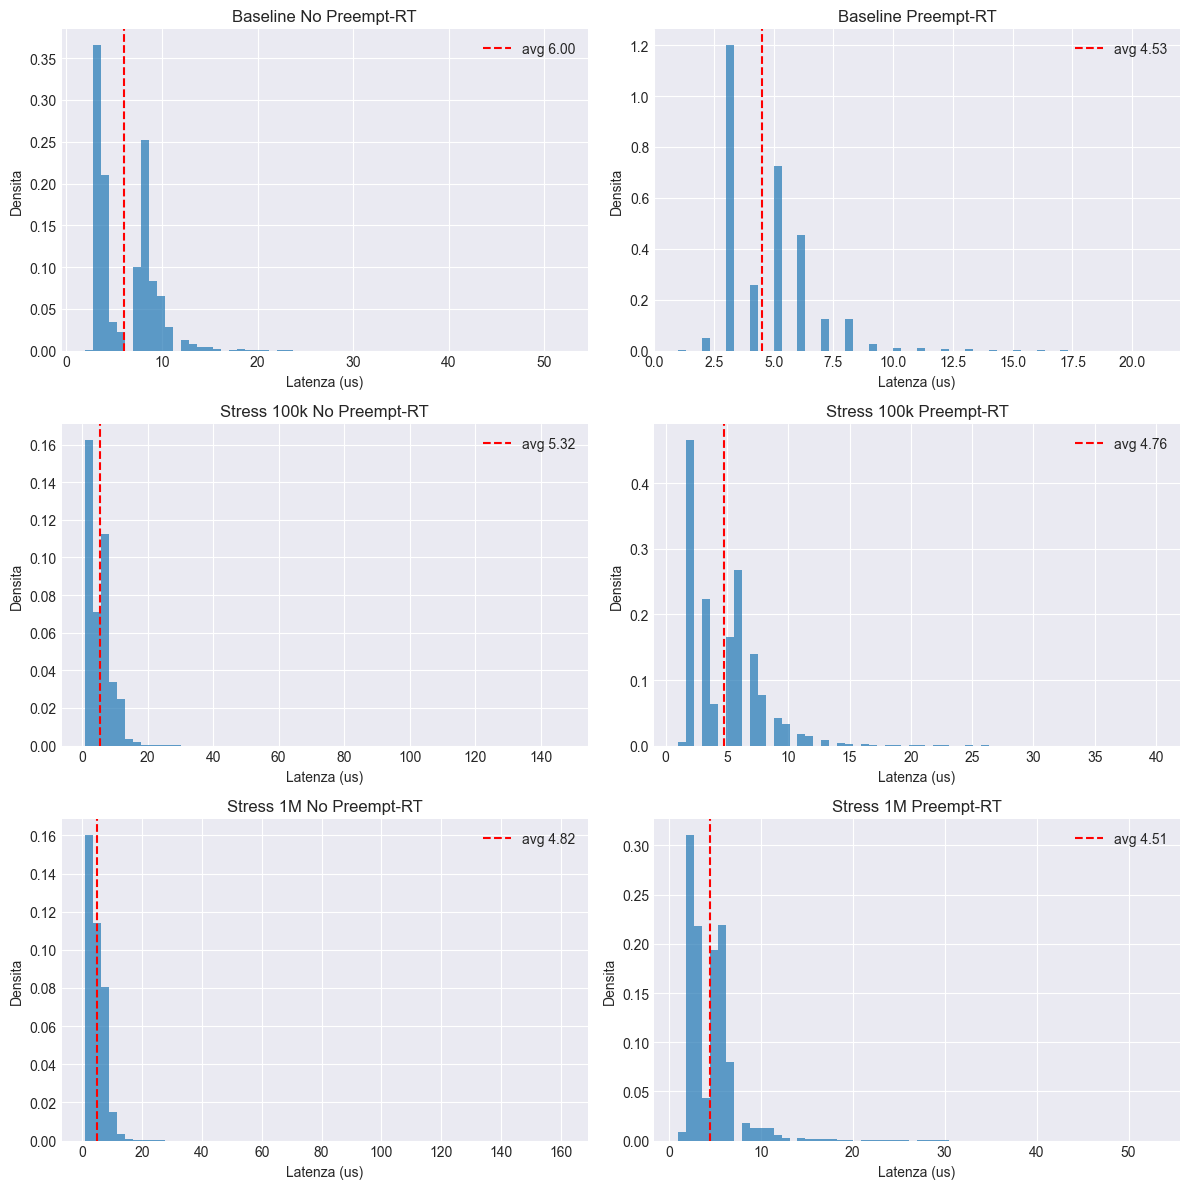

In [9]:
# Distribuzione delle latenze per scenario
if latency_df.empty:
    print('Nessuna latenza disponibile per le distribuzioni')
else:
    scenarios = latency_df['scenario'].unique()
    n = len(scenarios)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=False)
    axes = axes.flat if n > 1 else [axes]
    for ax, sc in zip(axes, scenarios):
        data = latency_df[latency_df.scenario == sc].latency
        ax.hist(data, bins=60, density=True, alpha=0.7, color='tab:blue')
        ax.axvline(data.mean(), color='red', linestyle='--', label=f"avg {data.mean():.2f}")
        ax.set_title(sc)
        ax.set_xlabel('Latenza (us)')
        ax.set_ylabel('Densita')
        ax.legend()
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


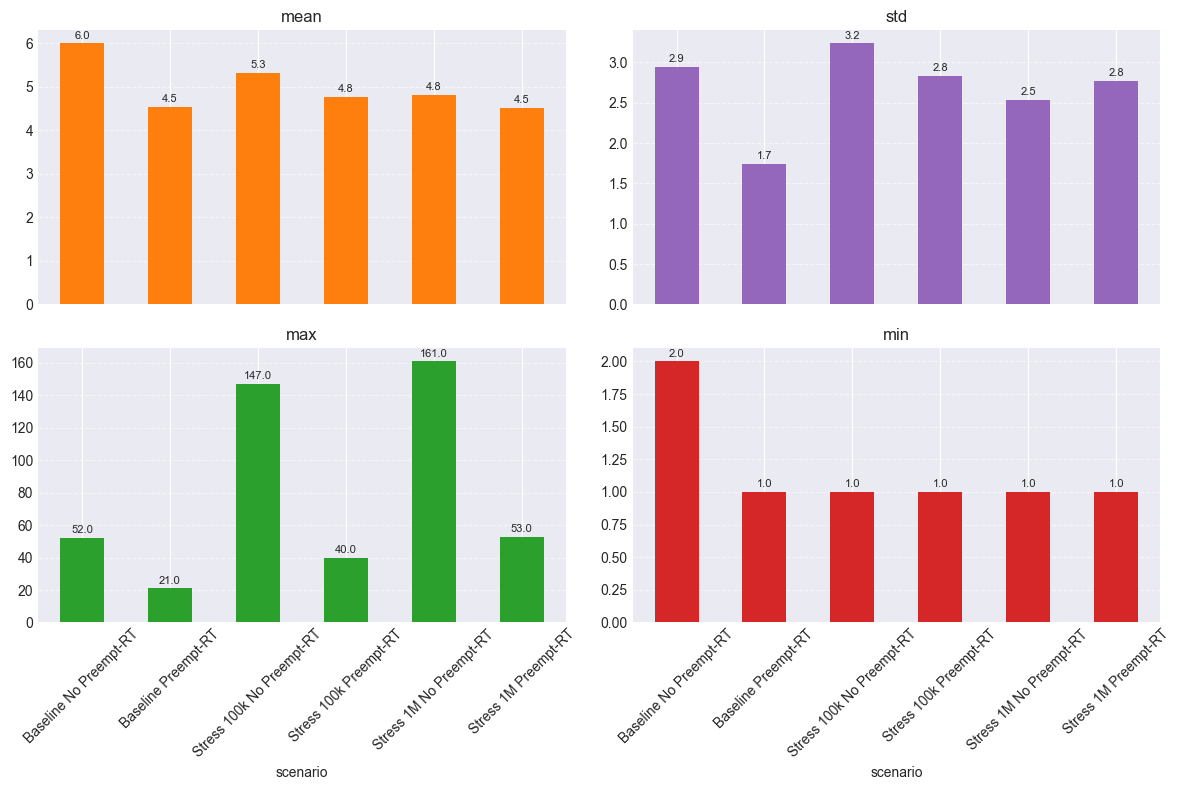

In [10]:
# Grafico riassuntivo: media, deviazione standard, max, min
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
metrics = ['mean', 'std', 'max', 'min']
colors = ['tab:orange', 'tab:purple', 'tab:green', 'tab:red']
for metric, color, ax in zip(metrics, colors, axes.flat):
    summary_df.plot(kind='bar', x='scenario', y=metric, ax=ax, legend=False, color=color)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=2, fontsize=8)
    ax.set_title(metric)
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


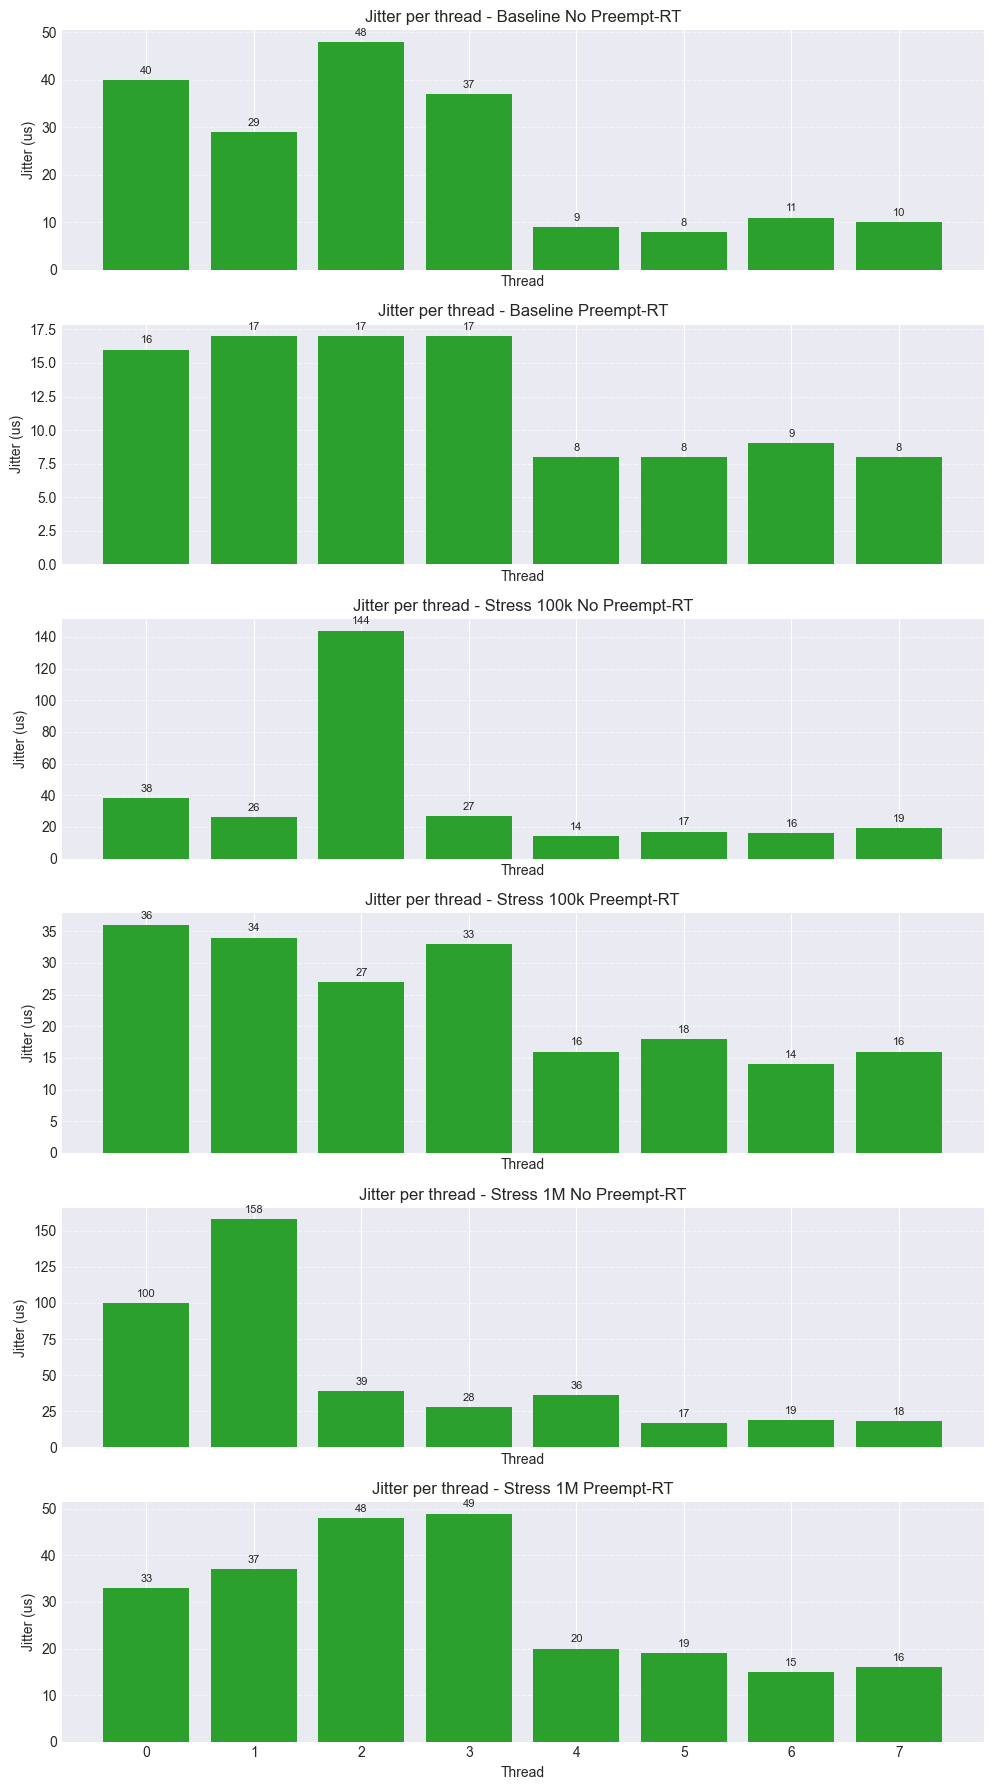

In [11]:
# Jitter per thread in ogni scenario
scenarios = summary_df['scenario'].tolist()
fig, axes = plt.subplots(len(scenarios), 1, figsize=(10, 3 * len(scenarios)), sharex=True)
if len(scenarios) == 1:
    axes = [axes]
for ax, sc in zip(axes, scenarios):
    tsub = thread_df[thread_df.scenario == sc]
    bars = ax.bar(tsub['thread'], tsub['jitter'], color='tab:green')
    ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
    ax.set_title(f'Jitter per thread - {sc}')
    ax.set_ylabel('Jitter (us)')
    ax.set_xlabel('Thread')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
